In [10]:
from scipy.optimize import curve_fit
import matplotlib.pylab as plt
import numpy as np
import os


In [40]:
def func(x, a, b):
    return a * x**2 + b * x 

x_data = [10, 25, 50, 100]
A_2f = [0.370, 0.905, 1.574, 2.571]
H_2f = [0.250, 0.606, 1.063, 1.793]
y_spread = [0.011, 0.015, 0.042, 0.079]

# averages and dispersion of data
#y_means = np.array(y_data).mean(axis = 1)
#y_spread = np.array(y_data).std(axis = 1)

best_fit_ab, covar = curve_fit(func, x_data, A_2f,
                               sigma = y_spread,
                               absolute_sigma = True)
sigma_ab = np.sqrt(np.diagonal(covar))

best_fit_ab2, covar2 = curve_fit(func, x_data, H_2f,
                               sigma = y_spread,
                               absolute_sigma = True)
sigma_ab2 = np.sqrt(np.diagonal(covar2))

B_2f = [0.459, 1.102, 1.982, 3.312]
G_2f = [0.308, 0.748, 1.352, 2.294]
y1_spread = [0.005, 0.015, 0.030, 0.061]
# Fitování pro druhý peak
best_fit_ab3, covar3 = curve_fit(func, x_data, B_2f,
                                 sigma=y1_spread,
                                 absolute_sigma=True)
sigma_ab3 = np.sqrt(np.diagonal(covar3))

best_fit_ab4, covar4 = curve_fit(func, x_data, G_2f,
                                 sigma=y1_spread,
                                 absolute_sigma=True)
sigma_ab4 = np.sqrt(np.diagonal(covar4))
B_2f = [0.459, 1.102, 1.982, 3.312]
G_2f = [0.308, 0.748, 1.352, 2.294]
y1_spread = [0.005, 0.015, 0.030, 0.061]
# Fitování pro druhý peak
best_fit_ab3, covar3 = curve_fit(func, x_data, B_2f,
                                 sigma=y1_spread,
                                 absolute_sigma=True)
sigma_ab3 = np.sqrt(np.diagonal(covar3))

best_fit_ab4, covar4 = curve_fit(func, x_data, G_2f,
                                 sigma=y1_spread,
                                 absolute_sigma=True)
sigma_ab4 = np.sqrt(np.diagonal(covar4))

In [41]:
from uncertainties import ufloat
a = ufloat(best_fit_ab[0], sigma_ab[0])
b = ufloat(best_fit_ab[1], sigma_ab[1])
text_res = "Best-fit (linear) parameters: \na = {}\nb = {}".format(a, b)
print(text_res)

a2 = ufloat(best_fit_ab2[0], sigma_ab2[0])
b2 = ufloat(best_fit_ab2[1], sigma_ab2[1])
text_res2 = "Best-fit (linear) parameters: \na = {}\nb = {}".format(a2, b2)
print(text_res2)

a3 = ufloat(best_fit_ab3[0], sigma_ab3[0])
b3 = ufloat(best_fit_ab3[1], sigma_ab3[1])
text_res3 = "Best-fit (linear) parameters: \na = {}\nb = {}".format(a3, b3)
print(text_res3)

a4 = ufloat(best_fit_ab4[0], sigma_ab4[0])
b4 = ufloat(best_fit_ab4[1], sigma_ab4[1])
text_res4 = "Best-fit parameters: \na = {}\nb = {}".format(a4, b4)
print(text_res4)

Best-fit (linear) parameters: 
a = -0.000135+/-0.000012
b = 0.0390+/-0.0007
Best-fit (linear) parameters: 
a = (-8.3+/-1.2)e-05
b = 0.0260+/-0.0007
Best-fit (linear) parameters: 
a = -0.000144+/-0.000008
b = 0.0473+/-0.0005
Best-fit parameters: 
a = (-8.9+/-0.8)e-05
b = 0.0318+/-0.0005


In [42]:
# plotting the unaveraged data
#flier_kwargs = dict(marker = 'o', markerfacecolor = 'silver',
#                    markersize = 3, alpha=0.7)
#line_kwargs = dict(color = 'k', linewidth = 1)

#bp = plt.boxplot(y_data, positions = x_data,
#                 capprops = line_kwargs,
#                 boxprops = line_kwargs,
#                 whiskerprops = line_kwargs,
#                 medianprops = line_kwargs,
#                 flierprops = flier_kwargs,
#                 widths = 5,
#                 manage_ticks = False)

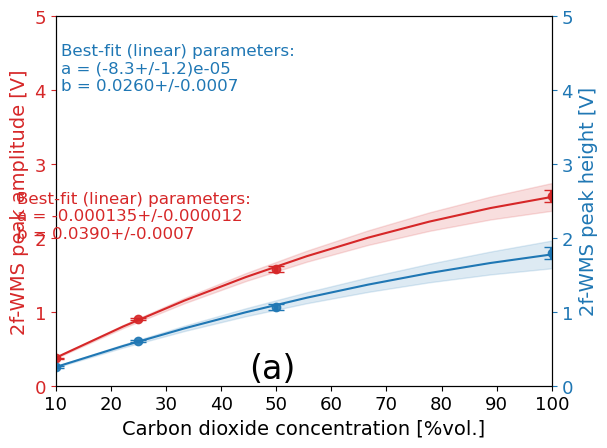

In [46]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Carbon dioxide concentration [%vol.]', fontsize=14)
ax1.set_ylabel('2f-WMS peak amplitude [V]', color=color, fontsize=14)
ax1.tick_params(axis='y', labelcolor=color)

#plt.errorbar(x_data, y_means, y_spread, fmt = 'none', ecolor = 'black')
ax1.errorbar(x_data, A_2f, y_spread, fmt='none', linewidth=3, capsize=6, ecolor = 'tab:red')
# plotting the averaged data with calculated dispersion
ax1.scatter(x_data, A_2f, marker='o', facecolor = 'tab:red', alpha = 0.9)

# plotting the model, 
hires_x = np.linspace(0, 100, 10)
ax1.plot(hires_x, func(hires_x, *best_fit_ab), 'tab:red')
bound_upper = func(hires_x, *(best_fit_ab + sigma_ab))
bound_lower = func(hires_x, *(best_fit_ab - sigma_ab))
# plotting the confidence intervals
ax1.fill_between(hires_x, bound_lower, bound_upper,
                 color = 'tab:red', alpha = 0.15)
ax1.tick_params(axis ='y', which ='major',  
               labelsize = 13, colors ='tab:red')
ax1.tick_params(axis ='x', which ='major', labelsize = 13)

plt.xlim(10, 100)
plt.ylim(0, 5)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color2 = 'tab:blue'
ax2.set_ylabel('2f-WMS peak height [V]', color=color2, fontsize=14)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor=color2)

#plt.errorbar(x_data, y_means, y_spread, fmt = 'none', ecolor = 'black')
ax2.errorbar(x_data, H_2f, y_spread, fmt='none', linewidth=3, capsize=6, ecolor = 'tab:blue')
# plotting the averaged data with calculated dispersion
ax2.scatter(x_data, H_2f, marker='o', facecolor = 'tab:blue', alpha = 0.9)

# plotting the model
hires_x = np.linspace(0, 100, 10)
ax2.plot(hires_x, func(hires_x, *best_fit_ab2), 'tab:blue')
bound_upper = func(hires_x, *(best_fit_ab2 + sigma_ab2))
bound_lower = func(hires_x, *(best_fit_ab2 - sigma_ab2))
# plotting the confidence intervals
ax2.fill_between(hires_x, bound_lower, bound_upper,
                 color = 'tab:blue', alpha = 0.15)
ax2.tick_params(axis ='y', which ='major',  
               labelsize = 13, colors ='tab:blue')
ax2.tick_params(axis ='x', which ='major', labelsize = 13)

plt.xlim(10, 100)
plt.ylim(0, 5)

plt.text(3, 2, text_res, color = 'tab:red', fontsize=12)
plt.text(11, 4, text_res2, color = 'tab:blue', fontsize=12)
plt.text(45, 0.1, "(a)", fontsize=24)


#plt.gcf().set_size_inches(6,6)
plt.savefig("best-fit_unc_A.png", dpi=600, bbox_inches='tight')
plt.savefig("best-fit_unc_A.pdf", dpi=600, bbox_inches='tight')
plt.show()

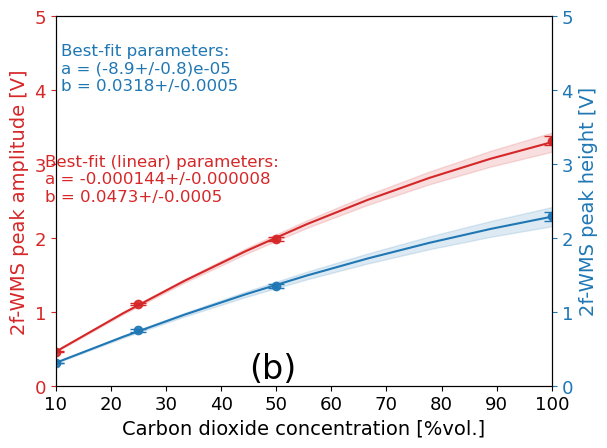

In [54]:
fig, ax3 = plt.subplots()

color = 'tab:red'
ax3.set_xlabel('Carbon dioxide concentration [%vol.]', fontsize=14)
ax3.set_ylabel('2f-WMS peak amplitude [V]', color=color, fontsize=14)
ax3.tick_params(axis='y', labelcolor=color)

#plt.errorbar(x_data, y_means, y_spread, fmt = 'none', ecolor = 'black')
ax3.errorbar(x_data, B_2f, y1_spread, fmt='none', linewidth=3, capsize=6, ecolor = 'tab:red')
# plotting the averaged data with calculated dispersion
ax3.scatter(x_data, B_2f, marker='o', facecolor = 'tab:red', alpha = 0.9)

# plotting the model, 
hires_x = np.linspace(0, 100, 10)
ax3.plot(hires_x, func(hires_x, *best_fit_ab3), 'tab:red')
bound_upper = func(hires_x, *(best_fit_ab3 + sigma_ab3))
bound_lower = func(hires_x, *(best_fit_ab3 - sigma_ab3))
# plotting the confidence intervals
ax3.fill_between(hires_x, bound_lower, bound_upper,
                 color = 'tab:red', alpha = 0.15)
ax3.tick_params(axis ='y', which ='major',  
               labelsize = 13, colors ='tab:red')
ax3.tick_params(axis ='x', which ='major', labelsize = 13)

plt.xlim(10, 100)
plt.ylim(0, 5)

ax4 = ax3.twinx()  # instantiate a second axes that shares the same x-axis

color2 = 'tab:blue'
ax4.set_ylabel('2f-WMS peak height [V]', color=color2, fontsize=14)  # we already handled the x-label with ax1
ax4.tick_params(axis='y', labelcolor=color2)

#plt.errorbar(x_data, y_means, y_spread, fmt = 'none', ecolor = 'black')
ax4.errorbar(x_data, G_2f, y1_spread, fmt='none', linewidth=3, capsize=6, ecolor = 'tab:blue')
# plotting the averaged data with calculated dispersion
ax4.scatter(x_data, G_2f, marker='o', facecolor = 'tab:blue', alpha = 0.9)

# plotting the model
hires_x = np.linspace(0, 100, 10)
ax4.plot(hires_x, func(hires_x, *best_fit_ab4), 'tab:blue')
bound_upper = func(hires_x, *(best_fit_ab4 + sigma_ab4))
bound_lower = func(hires_x, *(best_fit_ab4 - sigma_ab4))
# plotting the confidence intervals
ax4.fill_between(hires_x, bound_lower, bound_upper,
                 color = 'tab:blue', alpha = 0.15)
ax4.tick_params(axis ='y', which ='major',  
               labelsize = 13, colors ='tab:blue')
ax4.tick_params(axis ='x', which ='major', labelsize = 13)

plt.xlim(10, 100)
plt.ylim(0, 5)

plt.text(8, 2.5, text_res3, color = 'tab:red', fontsize=12)
plt.text(11, 4, text_res4, color = 'tab:blue', fontsize=12)
plt.text(45, 0.1, "(b)", fontsize=24)


#plt.gcf().set_size_inches(6,6)
plt.savefig("best-fit_unc_A1.png", dpi=600, bbox_inches='tight')
plt.savefig("best-fit_unc_A1.pdf", dpi=600, bbox_inches='tight')
plt.show()